# Simple descriptive analysis of the FNF student survey

This notebook presents one table at a time to understand each variable in the survey. The code is deliberately repetitive and simple: after the setup, most tables require only one line such as `frequency_table("gender")`.

The results are descriptive. 

## How to read the tables

- **Frequency** is the number of respondents selecting a response.
- **Valid percent** excludes blank or skipped observations from the denominator.
- Conditional questions can have many skips. Their denominator is printed immediately above the table.
- “Most common” does not mean that a majority selected the response.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# This works when the notebook is opened from either the project root or 3_analysis.
project_root = Path.cwd()
if project_root.name == "3_analysis":
    project_root = project_root.parent

data_path = project_root / "1_data" / "2_clean" / "student_survey_cleaned.dta"
output_dir = project_root / "6_output" / "descriptive_analysis_simple"
output_dir.mkdir(parents=True, exist_ok=True)

# One labelled copy for readable tables and one numeric copy for percentages in figures.
df = pd.read_stata(data_path, convert_categoricals=True)
df_num = pd.read_stata(data_path, convert_categoricals=False)
reader = pd.io.stata.StataReader(data_path)
variable_labels = reader.variable_labels()

print(f"Loaded {len(df):,} interviews and {df.shape[1]:,} variables.")

Loaded 836 interviews and 114 variables.


In [2]:
def frequency_table(variable, labels=None):
    # Make one simple frequency table.
    s = df[variable]

    # Blank text means missing.
    if s.dtype == object:
        s = s.replace(r"^\s*$", pd.NA, regex=True)

    # Optional labels are used for the coded non-voting reasons.
    if labels is not None:
        s = s.astype(object).replace(labels)

    counts = s.value_counts(dropna=True, sort=False)
    counts = counts[counts > 0]
    valid_n = int(s.notna().sum())

    table = counts.rename_axis("Response").reset_index(name="Frequency")
    table["Response"] = table["Response"].astype(object).replace({-99: "Prefer not to say"}).astype(str)
    table["Valid percent"] = (100 * table["Frequency"] / valid_n).round(1)

    print(variable_labels.get(variable, variable))
    print(f"Valid N = {valid_n:,}; missing or skipped = {len(s) - valid_n:,}")
    return table


def top_two_percent(variables):
    # Codes 1 and 2 are the top two responses in the ordered five-point questions.
    rows = []
    for variable in variables:
        s = pd.to_numeric(df_num[variable], errors="coerce")
        valid = s[s.isin([1, 2, 3, 4, 5])]
        rows.append({
            "Variable": variable,
            "Item": variable_labels.get(variable, variable).split(": ", 1)[-1],
            "Top two percent": round(100 * valid.isin([1, 2]).mean(), 1),
        })
    return pd.DataFrame(rows)


NOT_VOTE_LABELS = {
    "1": "Did not register",
    "2": "Away from registered voting location",
    "3": "Health or family issue",
    "4": "Not interested in voting",
    "5": "Did not trust parties or candidates",
    "6": "Intentionally boycotted the election",
    "7": "Felt vote would make no difference",
    "8": "Prefer not to say",
    "9": "Other",
    "others_please_specify": "Other",
}

## 1. Sample and location

### Age in completed years

In [3]:
age = pd.to_numeric(df_num["age"], errors="coerce")
age_summary = pd.DataFrame({
    "Statistic": ["Valid N", "Mean", "Standard deviation", "Minimum", "Median", "Maximum"],
    "Value": [age.count(), age.mean(), age.std(), age.min(), age.median(), age.max()],
})
age_summary["Value"] = age_summary["Value"].round(1)
age_summary

,Statistic,Value
0,Valid N,836.0
1,Mean,22.2
2,Standard deviation,2.6
3,Minimum,18.0
4,Median,22.0
5,Maximum,34.0


**Interpretation.** The median respondent was 22 years old. The middle half of respondents were between 20 and 23 years old.

### Province

In [4]:
frequency_table("Province")

Province
Valid N = 834; missing or skipped = 2


,Response,Frequency,Valid percent
0,bagamati,205,24.6
1,gandaki,63,7.6
2,karnali,45,5.4
3,koshi,136,16.3
4,lumbini,139,16.7
5,madhesh,167,20.0
6,sudurpaschim,79,9.5


**Interpretation.** The most common valid response was **bagamati** (205 respondents; 24.6%). The valid denominator is 834. 2 observations are blank or missing.

### Local government: standardized type

In [5]:
frequency_table("lg_type")

Local government: standardized type
Valid N = 834; missing or skipped = 2


,Response,Frequency,Valid percent
0,Metropolitan City,255,30.6
1,Municipality,210,25.2
2,Sub-Metropolitan City,369,44.2


**Interpretation.** The most common valid response was **Sub-Metropolitan City** (369 respondents; 44.2%). The valid denominator is 834. 2 observations are blank or missing.

### Local government: standardized name

In [6]:
frequency_table("lg_name")

Local government: standardized name
Valid N = 834; missing or skipped = 2


,Response,Frequency,Valid percent
0,Biratnagar,135,16.2
1,Birendranagar,45,5.4
2,Butwal,65,7.8
3,Dhangadhi,78,9.4
4,Janakpurdham,168,20.1
5,Kathmandu,115,13.8
6,Lalitpur,5,0.6
7,Pokhara,68,8.2
8,Siddharthanagar,75,9.0
9,Tarakeshwar,27,3.2


**Interpretation.** The most common valid response was **Janakpurdham** (168 respondents; 20.1%). The valid denominator is 834. 2 observations are blank or missing.

### Figure 1. Age distribution

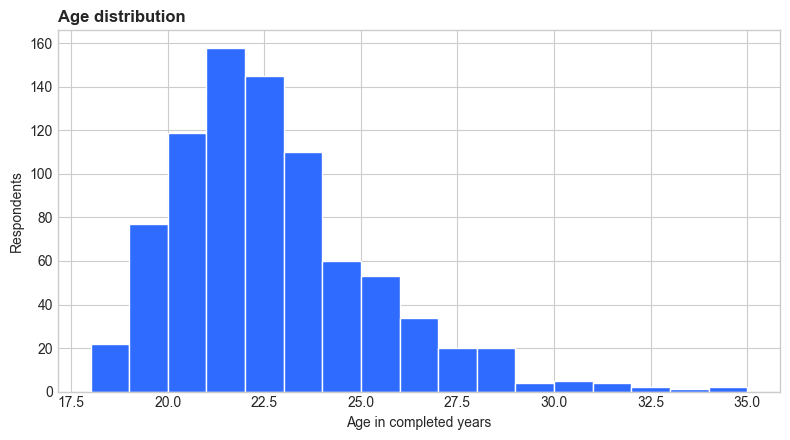

In [7]:
plt.figure(figsize=(8, 4.5))
plt.hist(age.dropna(), bins=range(int(age.min()), int(age.max()) + 2), color="#2F6BFF", edgecolor="white")
plt.title("Age distribution", loc="left", weight="bold")
plt.xlabel("Age in completed years")
plt.ylabel("Respondents")
plt.tight_layout()
plt.savefig(output_dir / "01_age_distribution.png", dpi=160)
plt.show()

**Interpretation.** The distribution is concentrated in the early twenties. The median age is 22, with relatively few respondents above age 30.

### Figure 2. Respondents by province

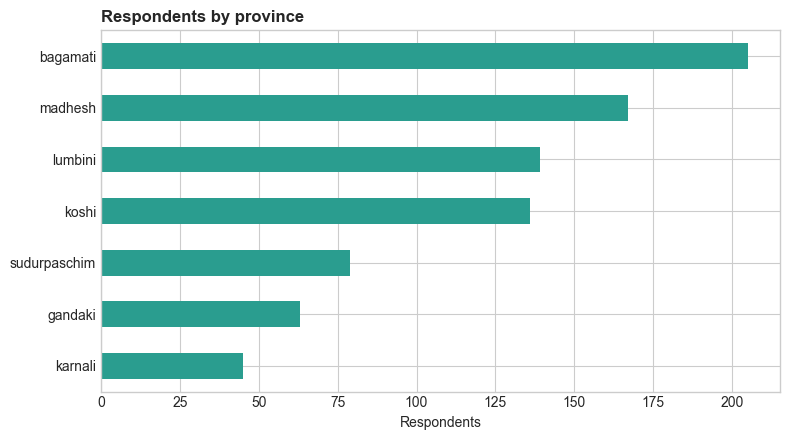

In [8]:
province_counts = df["Province"].value_counts().sort_values()
plt.figure(figsize=(8, 4.5))
province_counts.plot(kind="barh", color="#2A9D8F")
plt.title("Respondents by province", loc="left", weight="bold")
plt.xlabel("Respondents")
plt.ylabel("")
plt.tight_layout()
plt.savefig(output_dir / "02_respondents_by_province.png", dpi=160)
plt.show()

**Interpretation.** bagamati contributes the largest number of interviews (205). These counts describe the achieved sample and should not be read as province population shares.

## 2. Demographics and education

### 1.2 Gender

In [9]:
frequency_table("gender")

1.2 Gender
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Male,451,53.9
1,Female,385,46.1


**Interpretation.** The most common valid response was **Male** (451 respondents; 53.9%). The valid denominator is 836.

### 1.3 Current education level and year

In [10]:
frequency_table("education")

1.3 Current education level and year
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Bachelors 1st year,155,18.5
1,Bachelors 2nd year,178,21.3
2,Bachelors 3rd year,212,25.4
3,Bachelors 4th year,182,21.8
4,Bachelors 5th year,16,1.9
5,Masters 1st year,63,7.5
6,Masters 2nd year,29,3.5
7,PHD,1,0.1


**Interpretation.** The most common valid response was **Bachelors 3rd year** (212 respondents; 25.4%). The valid denominator is 836.

### 1.3.1 SLC/SEE school: private or public

In [11]:
frequency_table("edu_school")

1.3.1 SLC/SEE school: private or public
Valid N = 835; missing or skipped = 1


,Response,Frequency,Valid percent
0,Private,429,51.4
1,Public,406,48.6


**Interpretation.** The most common valid response was **Private** (429 respondents; 51.4%). The valid denominator is 835. 1 observations are blank or missing.

### 1.3.2 Plus-two institution: private or public

In [12]:
frequency_table("edu_plus2")

1.3.2 Plus-two institution: private or public
Valid N = 835; missing or skipped = 1


,Response,Frequency,Valid percent
0,Private,486,58.2
1,Public,349,41.8


**Interpretation.** The most common valid response was **Private** (486 respondents; 58.2%). The valid denominator is 835. 1 observations are blank or missing.

### 1.3.3 Bachelor's institution: private or public

In [13]:
frequency_table("edu_bachelors")

1.3.3 Bachelor's institution: private or public
Valid N = 93; missing or skipped = 743


,Response,Frequency,Valid percent
0,Private,19,20.4
1,Public,74,79.6


**Interpretation.** The most common valid response was **Public** (74 respondents; 79.6%). The valid denominator is 93. There are 743 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### 1.3.4 Master's or higher institution: private or public

In [14]:
frequency_table("edu_masters")

1.3.4 Master's or higher institution: private or public
Valid N = 64; missing or skipped = 772


,Response,Frequency,Valid percent
0,Private,10,15.6
1,Public,54,84.4


**Interpretation.** The most common valid response was **Public** (54 respondents; 84.4%). The valid denominator is 64. There are 772 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### Ethnicity

In [15]:
frequency_table("ethnicity")

Ethnicity
Valid N = 835; missing or skipped = 1


,Response,Frequency,Valid percent
0,Bhramin/Chettri,354,42.4
1,Dalit,62,7.4
2,Janajati,154,18.4
3,Muslim,18,2.2
4,Madhesi,247,29.6


**Interpretation.** The most common valid response was **Bhramin/Chettri** (354 respondents; 42.4%). The valid denominator is 835. 1 observations are blank or missing.

### 1.5 Considers self a person with religious beliefs

In [16]:
frequency_table("religious_belief")

1.5 Considers self a person with religious beliefs
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,823,98.4
1,No,12,1.4
2,Not Sure,1,0.1


**Interpretation.** The most common valid response was **Yes** (823 respondents; 98.4%). The valid denominator is 836.

### Religion

In [17]:
frequency_table("religion")

Religion
Valid N = 822; missing or skipped = 14


,Response,Frequency,Valid percent
0,Hindu,726,88.3
1,Muslim,21,2.6
2,Christian,29,3.5
3,Others,11,1.3
4,prefer_not_to_say,2,0.2
5,Buddhist,33,4.0


**Interpretation.** The most common valid response was **Hindu** (726 respondents; 88.3%). The valid denominator is 822. 14 observations are blank or missing.

### 1.7 Marital status

In [18]:
frequency_table("marital_status")

1.7 Marital status
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Never Married,776,92.8
1,Married,60,7.2


**Interpretation.** The most common valid response was **Never Married** (776 respondents; 92.8%). The valid denominator is 836.

### 1.8 Urban/rural location of most of life

In [19]:
frequency_table("life_place")

1.8 Urban/rural location of most of life
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Urban,487,58.3
1,Rural,349,41.7


**Interpretation.** The most common valid response was **Urban** (487 respondents; 58.3%). The valid denominator is 836.

The institution-type questions are conditional. For example, the bachelor's and master's tables only describe respondents with recorded answers to those follow-ups.

## 3. Migration background and plans

### 1.9 Close family member has lived or lives abroad

In [20]:
frequency_table("family_abroad")

1.9 Close family member has lived or lives abroad
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,355,42.5
1,No,481,57.5


**Interpretation.** The most common valid response was **No** (481 respondents; 57.5%). The valid denominator is 836.

### 1.9.1 Family member abroad returned permanently

In [21]:
frequency_table("family_returned")

1.9.1 Family member abroad returned permanently
Valid N = 355; missing or skipped = 481


,Response,Frequency,Valid percent
0,Yes,57,16.1
1,No,297,83.7
2,Not Sure,1,0.3


**Interpretation.** The most common valid response was **No** (297 respondents; 83.7%). The valid denominator is 355. There are 481 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### 1.10 Plans to go abroad or stay in Nepal

In [22]:
frequency_table("migration_plan")

1.10 Plans to go abroad or stay in Nepal


Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Go Abroad,309,37.0
1,Stay in Nepal,421,50.4
2,Don't Know,106,12.7


**Interpretation.** The most common valid response was **Stay in Nepal** (421 respondents; 50.4%). The valid denominator is 836.

### 1.10.1a Purpose of going abroad

In [23]:
frequency_table("abroad_purpose")

1.10.1a Purpose of going abroad
Valid N = 309; missing or skipped = 527


,Response,Frequency,Valid percent
0,Study,61,19.7
1,Work,68,22.0
2,Study and Work,172,55.7
3,Travel,8,2.6


**Interpretation.** The most common valid response was **Study and Work** (172 respondents; 55.7%). The valid denominator is 309. There are 527 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### 1.10.1b Plans while staying in Nepal

In [24]:
frequency_table("nepal_plan")

1.10.1b Plans while staying in Nepal
Valid N = 421; missing or skipped = 415


,Response,Frequency,Valid percent
0,Study Further,138,32.8
1,Seek a Job,6,1.4
2,Start a business,14,3.3
3,Study and Seek a job,224,53.2
4,Study and Start a business,35,8.3
5,Seek a job and Start a business,4,1.0


**Interpretation.** The most common valid response was **Study and Seek a job** (224 respondents; 53.2%). The valid denominator is 421. There are 415 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### Figure 3. Plans to go abroad or remain in Nepal

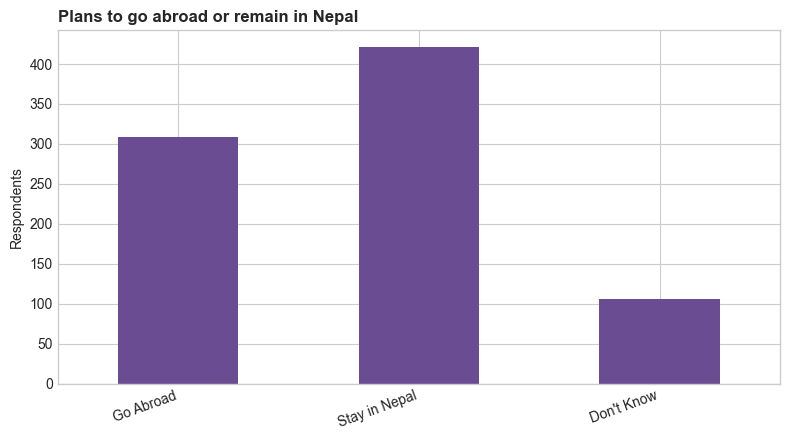

In [25]:
migration_counts = df["migration_plan"].value_counts(sort=False)
plt.figure(figsize=(8, 4.5))
migration_counts.plot(kind="bar", color="#6A4C93")
plt.title("Plans to go abroad or remain in Nepal", loc="left", weight="bold")
plt.xlabel("")
plt.ylabel("Respondents")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "03_migration_intentions.png", dpi=160)
plt.show()

**Interpretation.** The most common migration response is **Stay in Nepal** (421 of 836 valid responses; 50.4%).

## 4. Political interest, voting and influence

### 2.1 Agreement: politics is central to living in Nepal

In [26]:
frequency_table("q2_1")

2.1 Agreement: politics is central to living in Nepal
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,86,10.3
1,Agree,234,28.0
2,Neutral,148,17.7
3,Disagree,210,25.1
4,Strongly Disagree,146,17.5
5,Prefer not to say,12,1.4


**Interpretation.** The most common valid response was **Agree** (234 respondents; 28.0%). The valid denominator is 836.

### 2.2 Frequency of following political news

In [27]:
frequency_table("q2_2")

2.2 Frequency of following political news
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Daily,446,53.3
1,Several times a week,211,25.2
2,Weekly,30,3.6
3,Occasionally,136,16.3
4,Never,13,1.6


**Interpretation.** The most common valid response was **Daily** (446 respondents; 53.3%). The valid denominator is 836.

### 2.3 Active involvement in politics/political organizations

In [28]:
frequency_table("q2_3")

2.3 Active involvement in politics/political organizations
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,169,20.2
1,No,667,79.8


**Interpretation.** The most common valid response was **No** (667 respondents; 79.8%). The valid denominator is 836.

### Voting in the 2022 elections

### 2.4 Voted in 2022 federal election

In [29]:
frequency_table("q2_4")

2.4 Voted in 2022 federal election
Valid N = 460; missing or skipped = 376


,Response,Frequency,Valid percent
0,Yes,228,49.6
1,No,224,48.7
2,Not Sure,8,1.7


**Interpretation.** The most common valid response was **Yes** (228 respondents; 49.6%). The valid denominator is 460. There are 376 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### 2.4.1 Reason for not voting: federal

In [30]:
frequency_table("q2_4_1", labels=NOT_VOTE_LABELS)

2.4.1 Reason for not voting: federal
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,,612,73.2
1,Did not register,161,19.3
2,Other,6,0.7
3,Felt vote would make no difference,4,0.5
4,Intentionally boycotted the election,7,0.8
5,Health or family issue,31,3.7
6,Not interested in voting,5,0.6
7,Did not trust parties or candidates,6,0.7
8,Prefer not to say,4,0.5


**Interpretation.** The most common valid response was **** (612 respondents; 73.2%). The valid denominator is 836.

### 2.5 Voted in 2022 provincial election

In [31]:
frequency_table("q2_5")

2.5 Voted in 2022 provincial election
Valid N = 228; missing or skipped = 608


,Response,Frequency,Valid percent
0,Yes,217,95.2
1,No,10,4.4
2,Not Sure,1,0.4


**Interpretation.** The most common valid response was **Yes** (217 respondents; 95.2%). The valid denominator is 228. There are 608 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### 2.5.1 Reason for not voting: provincial

In [32]:
frequency_table("q2_5_1", labels=NOT_VOTE_LABELS)

2.5.1 Reason for not voting: provincial
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,,826,98.8
1,Did not trust parties or candidates,2,0.2
2,Did not register,4,0.5
3,Health or family issue,2,0.2
4,Not interested in voting,2,0.2


**Interpretation.** The most common valid response was **** (826 respondents; 98.8%). The valid denominator is 836.

### 2.6 Voted in 2022 local election

In [33]:
frequency_table("q2_6")

2.6 Voted in 2022 local election
Valid N = 460; missing or skipped = 376


,Response,Frequency,Valid percent
0,Yes,222,48.3
1,No,228,49.6
2,Not Sure,10,2.2


**Interpretation.** The most common valid response was **No** (228 respondents; 49.6%). The valid denominator is 460. There are 376 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### 2.6.1 Reason for not voting: local

In [34]:
frequency_table("q2_6_1", labels=NOT_VOTE_LABELS)

2.6.1 Reason for not voting: local
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,,608,72.7
1,Did not register,160,19.1
2,Other,8,1.0
3,Felt vote would make no difference,3,0.4
4,Intentionally boycotted the election,5,0.6
5,Health or family issue,36,4.3
6,Not interested in voting,6,0.7
7,Did not trust parties or candidates,6,0.7
8,Prefer not to say,4,0.5


**Interpretation.** The most common valid response was **** (608 respondents; 72.7%). The valid denominator is 836.

The election questions have different valid denominators because they were routed by age and previous answers. Compare percentages, not raw counts, across the three elections.

### 2.7 Likelihood of voting in 2027 local elections

In [35]:
frequency_table("q2_7")

2.7 Likelihood of voting in 2027 local elections
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Very Likely,544,65.1
1,Somewhat Likely,159,19.0
2,Somewhat Unlikely,25,3.0
3,Very Unlikely,59,7.1
4,Donot Know,49,5.9


**Interpretation.** The most common valid response was **Very Likely** (544 respondents; 65.1%). The valid denominator is 836.

### 2.7.1 Reason unlikely to vote in 2027 local elections

In [36]:
frequency_table("q2_7_1")

2.7.1 Reason unlikely to vote in 2027 local elections
Valid N = 84; missing or skipped = 752


,Response,Frequency,Valid percent
0,Did not register,41,48.8
1,Away from registerd voting location,17,20.2
2,Health/Family issue,11,13.1
3,Not interested in voting process,12,14.3
4,Didnot trust political parties/candidates,2,2.4
5,Intentionally boycotted the election,1,1.2


**Interpretation.** The most common valid response was **Did not register** (41 respondents; 48.8%). The valid denominator is 84. There are 752 blanks or routed skips, so this question should be interpreted using its valid denominator rather than the full sample.

### 2.9 Confidence in influencing government decisions

In [37]:
frequency_table("q2_9")

2.9 Confidence in influencing government decisions
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Very Confident,329,39.4
1,Confident,354,42.3
2,Neutral,112,13.4
3,Not Confident,34,4.1
4,Not at all confident,7,0.8


**Interpretation.** The most common valid response was **Confident** (354 respondents; 42.3%). The valid denominator is 836.

### Figure 4. Participation in the 2022 elections

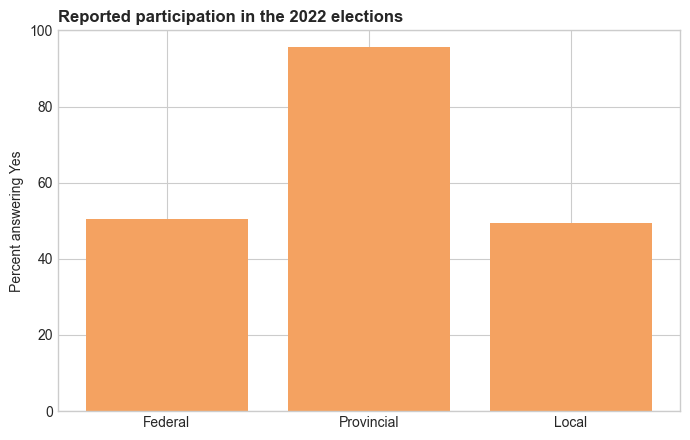

In [38]:
election_variables = ["q2_4", "q2_5", "q2_6"]
election_names = ["Federal", "Provincial", "Local"]
election_percent = []

for variable in election_variables:
    s = pd.to_numeric(df_num[variable], errors="coerce")
    valid = s[s.isin([1, 2])]
    election_percent.append(100 * valid.eq(1).mean())

plt.figure(figsize=(7, 4.5))
plt.bar(election_names, election_percent, color="#F4A261")
plt.title("Reported participation in the 2022 elections", loc="left", weight="bold")
plt.ylabel("Percent answering Yes")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / "04_election_participation.png", dpi=160)
plt.show()

**Interpretation.** Among valid responses, reported participation is highest for the **Provincial election** (95.6%). The denominators differ, so this is a comparison of percentages among respondents asked each question.

## 5. Civic and political participation during the past 12 months

### 2.8.1 Past 12 months: Attended campaign/rally

In [39]:
frequency_table("q2_8_1")

2.8.1 Past 12 months: Attended campaign/rally
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,175,20.9
1,No,661,79.1


**Interpretation.** The most common valid response was **No** (661 respondents; 79.1%). The valid denominator is 836.

### 2.8.2 Past 12 months: Volunteered for party/campaign

In [40]:
frequency_table("q2_8_2")

2.8.2 Past 12 months: Volunteered for party/campaign
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,89,10.6
1,No,747,89.4


**Interpretation.** The most common valid response was **No** (747 respondents; 89.4%). The valid denominator is 836.

### 2.8.3 Past 12 months: Joined protest/demonstration

In [41]:
frequency_table("q2_8_3")

2.8.3 Past 12 months: Joined protest/demonstration
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,246,29.4
1,No,590,70.6


**Interpretation.** The most common valid response was **No** (590 respondents; 70.6%). The valid denominator is 836.

### 2.8.4 Past 12 months: Joined public meeting/discussion

In [42]:
frequency_table("q2_8_4")

2.8.4 Past 12 months: Joined public meeting/discussion
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,265,31.7
1,No,571,68.3


**Interpretation.** The most common valid response was **No** (571 respondents; 68.3%). The valid denominator is 836.

### 2.8.5 Past 12 months: Contacted elected representative

In [43]:
frequency_table("q2_8_5")

2.8.5 Past 12 months: Contacted elected representative
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,169,20.2
1,No,667,79.8


**Interpretation.** The most common valid response was **No** (667 respondents; 79.8%). The valid denominator is 836.

### 2.8.6 Past 12 months: Joined ward user committee

In [44]:
frequency_table("q2_8_6")

2.8.6 Past 12 months: Joined ward user committee
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Yes,37,4.4
1,No,799,95.6


**Interpretation.** The most common valid response was **No** (799 respondents; 95.6%). The valid denominator is 836.

### Figure 5. Civic and political activities

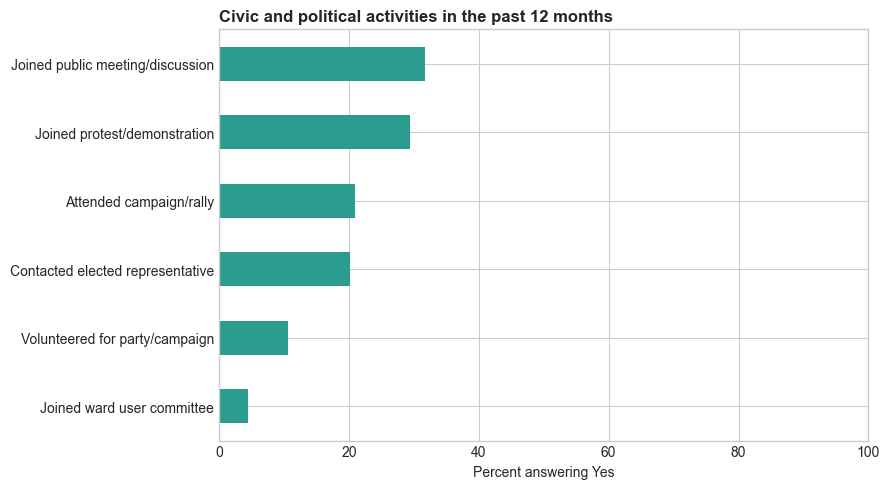

In [45]:
civic_variables = ["q2_8_1", "q2_8_2", "q2_8_3", "q2_8_4", "q2_8_5", "q2_8_6"]
civic_labels = [variable_labels[v].split(": ", 1)[-1] for v in civic_variables]
civic_percent = []

for variable in civic_variables:
    s = pd.to_numeric(df_num[variable], errors="coerce")
    valid = s[s.isin([1, 2])]
    civic_percent.append(100 * valid.eq(1).mean())

civic_plot = pd.Series(civic_percent, index=civic_labels).sort_values()
plt.figure(figsize=(9, 5))
civic_plot.plot(kind="barh", color="#2A9D8F")
plt.title("Civic and political activities in the past 12 months", loc="left", weight="bold")
plt.xlabel("Percent answering Yes")
plt.ylabel("")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / "05_civic_participation.png", dpi=160)
plt.show()

**Interpretation.** The most commonly reported activity is **Joined public meeting/discussion** (31.7%). The least commonly reported activity is **Joined ward user committee** (4.4%).

## 6. Political stability in Nepal

### Proposed causes of political instability

### Nepal instability cause: Government changes/party conflict

In [46]:
frequency_table("q3_1_1")

Nepal instability cause: Government changes/party conflict
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,2,0.2
1,Strongly Agree,388,46.4
2,Agree,384,45.9
3,Neutral,39,4.7
4,Disagree,16,1.9
5,Strongly Disagree,3,0.4
6,Prefer not to say,4,0.5


**Interpretation.** The most common valid response was **Strongly Agree** (388 respondents; 46.4%). The valid denominator is 836.

### Nepal instability cause: Policy formulation failure

In [47]:
frequency_table("q3_1_2")

Nepal instability cause: Policy formulation failure
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,374,44.7
1,Agree,401,48.0
2,Neutral,27,3.2
3,Disagree,25,3.0
4,Strongly Disagree,8,1.0
5,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Agree** (401 respondents; 48.0%). The valid denominator is 836.

### Nepal instability cause: Policy implementation failure

In [48]:
frequency_table("q3_1_2_001")

Nepal instability cause: Policy implementation failure
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,3,0.4
1,Strongly Agree,412,49.3
2,Agree,370,44.3
3,Neutral,34,4.1
4,Disagree,13,1.6
5,Strongly Disagree,4,0.5


**Interpretation.** The most common valid response was **Strongly Agree** (412 respondents; 49.3%). The valid denominator is 836.

### Nepal instability cause: Corruption

In [49]:
frequency_table("q3_1_3")

Nepal instability cause: Corruption
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,479,57.3
1,Agree,320,38.3
2,Neutral,20,2.4
3,Disagree,9,1.1
4,Strongly Disagree,5,0.6
5,Prefer not to say,3,0.4


**Interpretation.** The most common valid response was **Strongly Agree** (479 respondents; 57.3%). The valid denominator is 836.

### Nepal instability cause: Lack of accountability

In [50]:
frequency_table("q3_1_3_001")

Nepal instability cause: Lack of accountability
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,2,0.2
1,Strongly Agree,350,41.9
2,Agree,418,50.0
3,Neutral,47,5.6
4,Disagree,19,2.3


**Interpretation.** The most common valid response was **Agree** (418 respondents; 50.0%). The valid denominator is 836.

### Nepal instability cause: Protests/violence/civic unrest

In [51]:
frequency_table("q3_1_4")

Nepal instability cause: Protests/violence/civic unrest
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,348,41.6
2,Agree,399,47.7
3,Neutral,52,6.2
4,Disagree,28,3.3
5,Strongly Disagree,7,0.8
6,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Agree** (399 respondents; 47.7%). The valid denominator is 836.

### Nepal instability cause: Transfers of government officials

In [52]:
frequency_table("q3_1_5")

Nepal instability cause: Transfers of government officials
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,159,19.0
1,Agree,373,44.6
2,Neutral,150,17.9
3,Disagree,116,13.9
4,Strongly Disagree,35,4.2
5,Prefer not to say,3,0.4


**Interpretation.** The most common valid response was **Agree** (373 respondents; 44.6%). The valid denominator is 836.

### Nepal instability cause: Conflict between government tiers

In [53]:
frequency_table("q3_1_6")

Nepal instability cause: Conflict between government tiers
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,306,36.6
1,Agree,437,52.3
2,Neutral,59,7.1
3,Disagree,33,3.9
4,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Agree** (437 respondents; 52.3%). The valid denominator is 836.

### Nepal instability cause: Foreign/external influence

In [54]:
frequency_table("q3_1_7")

Nepal instability cause: Foreign/external influence
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,237,28.3
2,Agree,390,46.7
3,Neutral,126,15.1
4,Disagree,57,6.8
5,Strongly Disagree,15,1.8
6,Prefer not to say,10,1.2


**Interpretation.** The most common valid response was **Agree** (390 respondents; 46.7%). The valid denominator is 836.

### Figure 6. Perceived causes of political instability

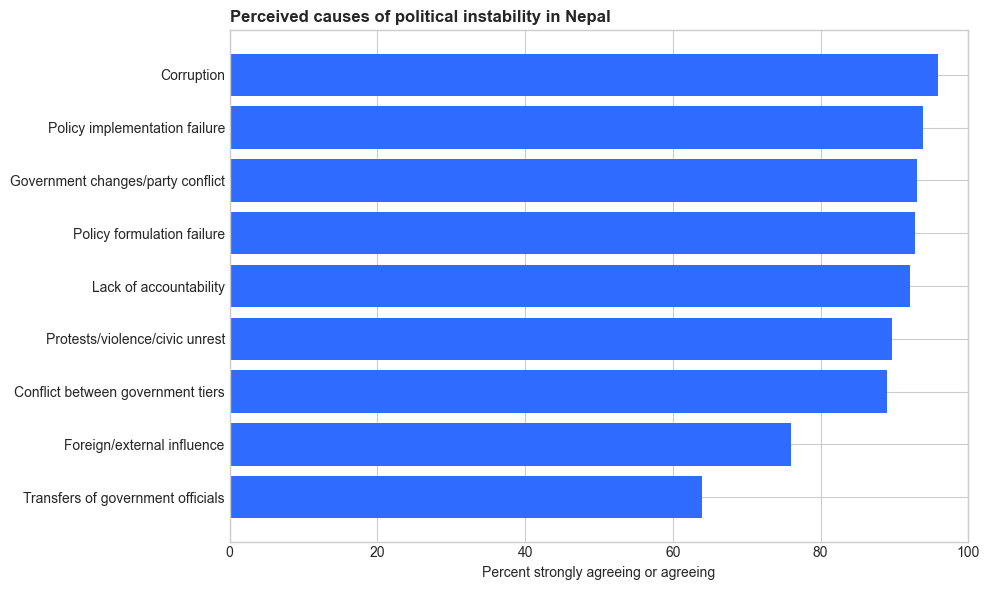

In [55]:
instability_variables = [
    "q3_1_1", "q3_1_2", "q3_1_2_001", "q3_1_3", "q3_1_3_001",
    "q3_1_4", "q3_1_5", "q3_1_6", "q3_1_7",
]
instability_plot = top_two_percent(instability_variables).sort_values("Top two percent")

plt.figure(figsize=(10, 6))
plt.barh(instability_plot["Item"], instability_plot["Top two percent"], color="#2F6BFF")
plt.title("Perceived causes of political instability in Nepal", loc="left", weight="bold")
plt.xlabel("Percent strongly agreeing or agreeing")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / "06_causes_of_instability.png", dpi=160)
plt.show()

**Interpretation.** The three causes receiving the most agreement are **Corruption** (95.9%); **Policy implementation failure** (93.9%); **Government changes/party conflict** (93.0%). This figure summarizes agreement; the individual tables above show all response categories.

### Current stability and expectations

### 3.2 Political stability of Nepal today

In [56]:
frequency_table("q3_2")

3.2 Political stability of Nepal today
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Very Stable,43,5.1
2,Stable,454,54.3
3,Neutral,184,22.0
4,Unstable,119,14.2
5,Very Unstable,26,3.1
6,Prefer not to say,9,1.1


**Interpretation.** The most common valid response was **Stable** (454 respondents; 54.3%). The valid denominator is 836.

### 3.3 Nepal stability compared with one year ago

In [57]:
frequency_table("q3_3")

3.3 Nepal stability compared with one year ago
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Much more stable,58,6.9
1,Somewhat more stable,564,67.5
2,About the same,135,16.1
3,Somewhat less stable,47,5.6
4,Much less stable,29,3.5
5,Prefer not to say,3,0.4


**Interpretation.** The most common valid response was **Somewhat more stable** (564 respondents; 67.5%). The valid denominator is 836.

### 3.4 Nepal stability compared with five years ago

In [58]:
frequency_table("q3_4")

3.4 Nepal stability compared with five years ago
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Much more stable,126,15.1
1,Somewhat more stable,497,59.4
2,About the same,122,14.6
3,Somewhat less stable,43,5.1
4,Much less stable,33,3.9
5,Prefer not to say,15,1.8


**Interpretation.** The most common valid response was **Somewhat more stable** (497 respondents; 59.4%). The valid denominator is 836.

### 3.5 Expected Nepal stability in five years

In [59]:
frequency_table("q3_5")

3.5 Expected Nepal stability in five years
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,3,0.4
1,Much more stable,239,28.6
2,Somewhat more stable,362,43.3
3,About the same,66,7.9
4,Somewhat less stable,23,2.8
5,Much less stable,30,3.6
6,Prefer not to say,113,13.5


**Interpretation.** The most common valid response was **Somewhat more stable** (362 respondents; 43.3%). The valid denominator is 836.

### 3.6 Likelihood government changes within one year

In [60]:
frequency_table("q3_6")

3.6 Likelihood government changes within one year
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Very Likely,43,5.1
1,Somewhat Likely,111,13.3
2,Somewhat Unlikely,169,20.2
3,Very Unlikely,128,15.3
4,Donot Know,385,46.1


**Interpretation.** The most common valid response was **Donot Know** (385 respondents; 46.1%). The valid denominator is 836.

### 3.7 Likelihood government changes before next federal election

In [61]:
frequency_table("q3_7")

3.7 Likelihood government changes before next federal election
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Very Likely,59,7.1
2,Somewhat Likely,140,16.7
3,Somewhat Unlikely,222,26.6
4,Very Unlikely,155,18.5
5,Donot Know,259,31.0


**Interpretation.** The most common valid response was **Donot Know** (259 respondents; 31.0%). The valid denominator is 836.

### 3.8 Likelihood of major political event within five years

In [62]:
frequency_table("q3_8")

3.8 Likelihood of major political event within five years
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Very Likely,91,10.9
1,Somewhat Likely,254,30.4
2,Somewhat Unlikely,274,32.8
3,Very Unlikely,115,13.8
4,Donot Know,102,12.2


**Interpretation.** The most common valid response was **Somewhat Unlikely** (274 respondents; 32.8%). The valid denominator is 836.

### 3.9 Likelihood of new political force within five years

In [63]:
frequency_table("q3_9")

3.9 Likelihood of new political force within five years
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Very Likely,92,11.0
1,Somewhat Likely,252,30.1
2,Somewhat Unlikely,200,23.9
3,Very Unlikely,119,14.2
4,Donot Know,173,20.7


**Interpretation.** The most common valid response was **Somewhat Likely** (252 respondents; 30.1%). The valid denominator is 836.

### Risks to political stability in Nepal

### Nepal stability risk: Corruption

In [64]:
frequency_table("q3_10_11")

Nepal stability risk: Corruption
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,535,64.0
2,Agree,266,31.8
3,Neutral,18,2.2
4,Disagree,12,1.4
5,Strongly Disagree,3,0.4
6,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Strongly Agree** (535 respondents; 64.0%). The valid denominator is 836.

### Nepal stability risk: Lack of accountability

In [65]:
frequency_table("q3_10_11_001")

Nepal stability risk: Lack of accountability
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,394,47.1
1,Agree,392,46.9
2,Neutral,36,4.3
3,Disagree,10,1.2
4,Strongly Disagree,3,0.4
5,Donot Know,1,0.1


**Interpretation.** The most common valid response was **Strongly Agree** (394 respondents; 47.1%). The valid denominator is 836.

### Nepal stability risk: Unemployment/economic opportunities

In [66]:
frequency_table("q3_10_12")

Nepal stability risk: Unemployment/economic opportunities
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,445,53.2
1,Agree,345,41.3
2,Neutral,27,3.2
3,Disagree,15,1.8
4,Strongly Disagree,3,0.4
5,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Strongly Agree** (445 respondents; 53.2%). The valid denominator is 836.

### Nepal stability risk: Political exclusion

In [67]:
frequency_table("q3_10_13")

Nepal stability risk: Political exclusion
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,2,0.2
1,Strongly Agree,327,39.1
2,Agree,402,48.1
3,Neutral,82,9.8
4,Disagree,22,2.6
5,Strongly Disagree,1,0.1


**Interpretation.** The most common valid response was **Agree** (402 respondents; 48.1%). The valid denominator is 836.

### Nepal stability risk: Rising cost of living

In [68]:
frequency_table("q3_10_14")

Nepal stability risk: Rising cost of living
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,330,39.5
1,Agree,406,48.6
2,Neutral,63,7.5
3,Disagree,30,3.6
4,Strongly Disagree,6,0.7
5,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Agree** (406 respondents; 48.6%). The valid denominator is 836.

### Nepal stability risk: Social media misinformation

In [69]:
frequency_table("q3_10_15")

Nepal stability risk: Social media misinformation
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,327,39.1
1,Agree,376,45.0
2,Neutral,92,11.0
3,Disagree,33,3.9
4,Strongly Disagree,8,1.0


**Interpretation.** The most common valid response was **Agree** (376 respondents; 45.0%). The valid denominator is 836.

### Nepal stability risk: Foreign/external influence

In [70]:
frequency_table("q3_10_16")

Nepal stability risk: Foreign/external influence
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,2,0.2
1,Strongly Agree,267,31.9
2,Agree,393,47.0
3,Neutral,115,13.8
4,Disagree,45,5.4
5,Strongly Disagree,8,1.0
6,Prefer not to say,6,0.7


**Interpretation.** The most common valid response was **Agree** (393 respondents; 47.0%). The valid denominator is 836.

### Nepal stability risk: Ethnic/religious conflict

In [71]:
frequency_table("q3_10_17")

Nepal stability risk: Ethnic/religious conflict
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,330,39.5
1,Agree,404,48.3
2,Neutral,56,6.7
3,Disagree,40,4.8
4,Strongly Disagree,4,0.5
5,Prefer not to say,2,0.2


**Interpretation.** The most common valid response was **Agree** (404 respondents; 48.3%). The valid denominator is 836.

### Sources of hope for Nepal

### Nepal hope: Governance/anti-corruption reforms

In [72]:
frequency_table("q3_11_1")

Nepal hope: Governance/anti-corruption reforms
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,164,19.6
2,Agree,414,49.5
3,Neutral,155,18.5
4,Disagree,56,6.7
5,Strongly Disagree,39,4.7
6,Prefer not to say,7,0.8


**Interpretation.** The most common valid response was **Agree** (414 respondents; 49.5%). The valid denominator is 836.

### Nepal hope: Youth political participation

In [73]:
frequency_table("q3_11_2")

Nepal hope: Youth political participation
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,252,30.1
1,Agree,429,51.3
2,Neutral,118,14.1
3,Disagree,26,3.1
4,Strongly Disagree,3,0.4
5,Prefer not to say,8,1.0


**Interpretation.** The most common valid response was **Agree** (429 respondents; 51.3%). The valid denominator is 836.

### Nepal hope: Improved democracy

In [74]:
frequency_table("q3_11_3")

Nepal hope: Improved democracy
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,141,16.9
1,Agree,414,49.5
2,Neutral,193,23.1
3,Disagree,60,7.2
4,Strongly Disagree,19,2.3
5,Prefer not to say,9,1.1


**Interpretation.** The most common valid response was **Agree** (414 respondents; 49.5%). The valid denominator is 836.

### Nepal hope: Economic/employment prospects

In [75]:
frequency_table("q3_11_4")

Nepal hope: Economic/employment prospects
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,112,13.4
2,Agree,370,44.3
3,Neutral,182,21.8
4,Disagree,104,12.4
5,Strongly Disagree,58,6.9
6,Prefer not to say,9,1.1


**Interpretation.** The most common valid response was **Agree** (370 respondents; 44.3%). The valid denominator is 836.

## 7. Nepal's Gen-Z protest

### 4.1 Attention to September 8 Gen-Z protest and subsequent politics

In [76]:
frequency_table("q4_1")

4.1 Attention to September 8 Gen-Z protest and subsequent politics
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Engaged Directly,224,26.8
1,Very Closely,477,57.1
2,Somewhat Closely,116,13.9
3,Heard But followed Vary Little,15,1.8
4,Not at All,4,0.5


**Interpretation.** The most common valid response was **Very Closely** (477 respondents; 57.1%). The valid denominator is 836.

### Proposed causes of the Gen-Z protest

### Gen-Z protest cause: Corruption

In [77]:
frequency_table("q4_2_1")

Gen-Z protest cause: Corruption
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,500,59.8
2,Agree,282,33.7
3,Neutral,22,2.6
4,Disagree,21,2.5
5,Strongly Disagree,9,1.1
6,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Strongly Agree** (500 respondents; 59.8%). The valid denominator is 836.

### Gen-Z protest cause: Poor public services

In [78]:
frequency_table("q4_2_2")

Gen-Z protest cause: Poor public services
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,368,44.0
1,Agree,338,40.4
2,Neutral,82,9.8
3,Disagree,39,4.7
4,Strongly Disagree,4,0.5
5,Prefer not to say,5,0.6


**Interpretation.** The most common valid response was **Strongly Agree** (368 respondents; 44.0%). The valid denominator is 836.

### Gen-Z protest cause: Unemployment/economic opportunities

In [79]:
frequency_table("q4_2_3")

Gen-Z protest cause: Unemployment/economic opportunities
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,362,43.3
1,Agree,350,41.9
2,Neutral,59,7.1
3,Disagree,46,5.5
4,Strongly Disagree,19,2.3


**Interpretation.** The most common valid response was **Strongly Agree** (362 respondents; 43.3%). The valid denominator is 836.

### Gen-Z protest cause: Rising cost of living

In [80]:
frequency_table("q4_2_4")

Gen-Z protest cause: Rising cost of living
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,198,23.7
1,Agree,330,39.5
2,Neutral,122,14.6
3,Disagree,135,16.1
4,Strongly Disagree,50,6.0
5,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Agree** (330 respondents; 39.5%). The valid denominator is 836.

### Gen-Z protest cause: Distrust of leaders/parties/institutions

In [81]:
frequency_table("q4_2_5")

Gen-Z protest cause: Distrust of leaders/parties/institutions
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,410,49.0
1,Agree,342,40.9
2,Neutral,55,6.6
3,Disagree,24,2.9
4,Strongly Disagree,3,0.4
5,Prefer not to say,2,0.2


**Interpretation.** The most common valid response was **Strongly Agree** (410 respondents; 49.0%). The valid denominator is 836.

### Gen-Z protest cause: Nepotism/elite capture

In [82]:
frequency_table("q4_2_6")

Gen-Z protest cause: Nepotism/elite capture
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,486,58.1
2,Agree,256,30.6
3,Neutral,56,6.7
4,Disagree,28,3.3
5,Strongly Disagree,6,0.7
6,Prefer not to say,3,0.4


**Interpretation.** The most common valid response was **Strongly Agree** (486 respondents; 58.1%). The valid denominator is 836.

### Gen-Z protest cause: Social media ban

In [83]:
frequency_table("q4_2_7")

Gen-Z protest cause: Social media ban
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,424,50.7
1,Agree,248,29.7
2,Neutral,96,11.5
3,Disagree,55,6.6
4,Strongly Disagree,11,1.3
5,Prefer not to say,2,0.2


**Interpretation.** The most common valid response was **Strongly Agree** (424 respondents; 50.7%). The valid denominator is 836.

### Gen-Z protest cause: Foreign/external influence

In [84]:
frequency_table("q4_2_8")

Gen-Z protest cause: Foreign/external influence
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,169,20.2
2,Agree,235,28.1
3,Neutral,155,18.5
4,Disagree,190,22.7
5,Strongly Disagree,69,8.3
6,Prefer not to say,17,2.0


**Interpretation.** The most common valid response was **Agree** (235 respondents; 28.1%). The valid denominator is 836.

### Figure 7. Perceived causes of the Gen-Z protest

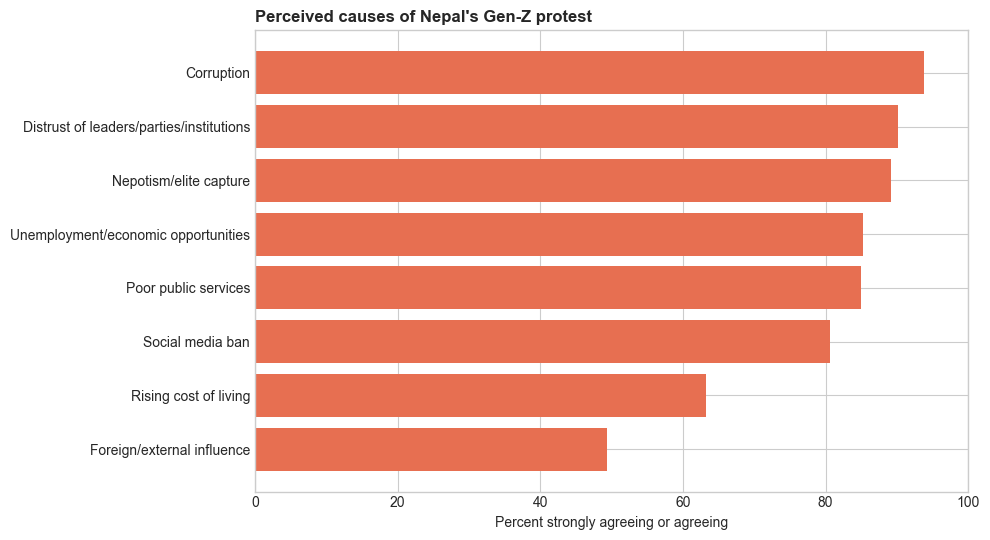

In [85]:
genz_cause_variables = ["q4_2_1", "q4_2_2", "q4_2_3", "q4_2_4", "q4_2_5", "q4_2_6", "q4_2_7", "q4_2_8"]
genz_plot = top_two_percent(genz_cause_variables).sort_values("Top two percent")

plt.figure(figsize=(10, 5.5))
plt.barh(genz_plot["Item"], genz_plot["Top two percent"], color="#E76F51")
plt.title("Perceived causes of Nepal's Gen-Z protest", loc="left", weight="bold")
plt.xlabel("Percent strongly agreeing or agreeing")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / "07_genz_protest_causes.png", dpi=160)
plt.show()

**Interpretation.** The three proposed causes receiving the most agreement are **Corruption** (93.8%); **Distrust of leaders/parties/institutions** (90.2%); **Nepotism/elite capture** (89.2%).

### Views on consequences and youth representation

### 4.3 Gen-Z protest: turning point in political history

In [86]:
frequency_table("q4_3")

4.3 Gen-Z protest: turning point in political history
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,2,0.2
1,Strongly Agree,407,48.7
2,Agree,358,42.8
3,Neutral,52,6.2
4,Disagree,10,1.2
5,Strongly Disagree,6,0.7
6,Prefer not to say,1,0.1


**Interpretation.** The most common valid response was **Strongly Agree** (407 respondents; 48.7%). The valid denominator is 836.

### 4.4 Gen-Z protest: greater youth civic/political participation

In [87]:
frequency_table("q4_4")

4.4 Gen-Z protest: greater youth civic/political participation
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,347,41.5
2,Agree,412,49.3
3,Neutral,49,5.9
4,Disagree,20,2.4
5,Strongly Disagree,4,0.5
6,Prefer not to say,3,0.4


**Interpretation.** The most common valid response was **Agree** (412 respondents; 49.3%). The valid denominator is 836.

### 4.5 Gen-Z protest: youth voices included in mainstream politics

In [88]:
frequency_table("q4_5")

4.5 Gen-Z protest: youth voices included in mainstream politics
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,260,31.1
2,Agree,442,52.9
3,Neutral,82,9.8
4,Disagree,36,4.3
5,Strongly Disagree,10,1.2
6,Prefer not to say,5,0.6


**Interpretation.** The most common valid response was **Agree** (442 respondents; 52.9%). The valid denominator is 836.

### 4.6 Gen-Z protest: increased public support for RSP

In [89]:
frequency_table("q4_6")

4.6 Gen-Z protest: increased public support for RSP
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,359,42.9
1,Agree,405,48.4
2,Neutral,51,6.1
3,Disagree,12,1.4
4,Strongly Disagree,4,0.5
5,Prefer not to say,5,0.6


**Interpretation.** The most common valid response was **Agree** (405 respondents; 48.4%). The valid denominator is 836.

### 4.7 Current government represents youth interests

In [90]:
frequency_table("q4_7")

4.7 Current government represents youth interests
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,239,28.6
1,Agree,407,48.7
2,Neutral,136,16.3
3,Disagree,32,3.8
4,Strongly Disagree,15,1.8
5,Prefer not to say,7,0.8


**Interpretation.** The most common valid response was **Agree** (407 respondents; 48.7%). The valid denominator is 836.

### 4.8 Government will continue to advance youth interests

In [91]:
frequency_table("q4_8")

4.8 Government will continue to advance youth interests
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,237,28.3
1,Agree,394,47.1
2,Neutral,142,17.0
3,Disagree,25,3.0
4,Strongly Disagree,24,2.9
5,Prefer not to say,14,1.7


**Interpretation.** The most common valid response was **Agree** (394 respondents; 47.1%). The valid denominator is 836.

## 8. Protest and political stability in South Asia

### 5.1 Attention to protests in other Asian countries

In [92]:
frequency_table("q5_1")

5.1 Attention to protests in other Asian countries
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Very Closely,74,8.9
2,Somewhat Closely,323,38.6
3,Not Very Closely,339,40.6
4,Not at all,99,11.8


**Interpretation.** The most common valid response was **Not Very Closely** (339 respondents; 40.6%). The valid denominator is 836.

### Proposed causes of dissent and protest

### South Asia dissent cause: Governance/corruption/public services

In [93]:
frequency_table("q5_2_1")

South Asia dissent cause: Governance/corruption/public services
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,247,29.5
2,Agree,447,53.5
3,Neutral,55,6.6
4,Disagree,25,3.0
5,Strongly Disagree,5,0.6
6,Prefer not to say,56,6.7


**Interpretation.** The most common valid response was **Agree** (447 respondents; 53.5%). The valid denominator is 836.

### South Asia dissent cause: Unemployment/economic opportunities

In [94]:
frequency_table("q5_2_2")

South Asia dissent cause: Unemployment/economic opportunities
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,2,0.2
1,Strongly Agree,230,27.5
2,Agree,457,54.7
3,Neutral,54,6.5
4,Disagree,25,3.0
5,Strongly Disagree,6,0.7
6,Prefer not to say,62,7.4


**Interpretation.** The most common valid response was **Agree** (457 respondents; 54.7%). The valid denominator is 836.

### South Asia dissent cause: Distrust of leaders/parties/institutions

In [95]:
frequency_table("q5_2_3")

South Asia dissent cause: Distrust of leaders/parties/institutions
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,2,0.2
1,Strongly Agree,263,31.5
2,Agree,395,47.2
3,Neutral,76,9.1
4,Disagree,18,2.2
5,Strongly Disagree,4,0.5
6,Prefer not to say,78,9.3


**Interpretation.** The most common valid response was **Agree** (395 respondents; 47.2%). The valid denominator is 836.

### South Asia dissent cause: Political exclusion

In [96]:
frequency_table("q5_2_4")

South Asia dissent cause: Political exclusion
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,4,0.5
1,Strongly Agree,174,20.8
2,Agree,359,42.9
3,Neutral,137,16.4
4,Disagree,62,7.4
5,Strongly Disagree,13,1.6
6,Prefer not to say,87,10.4


**Interpretation.** The most common valid response was **Agree** (359 respondents; 42.9%). The valid denominator is 836.

### South Asia dissent cause: Nepotism/elite capture

In [97]:
frequency_table("q5_2_5")

South Asia dissent cause: Nepotism/elite capture
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,2,0.2
1,Strongly Agree,225,26.9
2,Agree,413,49.4
3,Neutral,83,9.9
4,Disagree,32,3.8
5,Strongly Disagree,5,0.6
6,Prefer not to say,76,9.1


**Interpretation.** The most common valid response was **Agree** (413 respondents; 49.4%). The valid denominator is 836.

### South Asia dissent cause: Foreign/external influence

In [98]:
frequency_table("q5_2_6")

South Asia dissent cause: Foreign/external influence
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,3,0.4
1,Strongly Agree,149,17.8
2,Agree,373,44.6
3,Neutral,141,16.9
4,Disagree,70,8.4
5,Strongly Disagree,12,1.4
6,Prefer not to say,88,10.5


**Interpretation.** The most common valid response was **Agree** (373 respondents; 44.6%). The valid denominator is 836.

### Regional protest effects, stability and outlook

### 5.3 Protests in one country encourage others in South Asia

In [99]:
frequency_table("q5_3")

5.3 Protests in one country encourage others in South Asia
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,252,30.1
2,Agree,364,43.5
3,Neutral,103,12.3
4,Disagree,71,8.5
5,Strongly Disagree,23,2.8
6,Prefer not to say,22,2.6


**Interpretation.** The most common valid response was **Agree** (364 respondents; 43.5%). The valid denominator is 836.

### 5.4 Political stability of South Asia today

In [100]:
frequency_table("q5_4")

5.4 Political stability of South Asia today
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Much more stable,23,2.8
1,Somewhat more stable,376,45.0
2,About the same,184,22.0
3,Somewhat less stable,168,20.1
4,Much less stable,18,2.2
5,Prefer not to say,67,8.0


**Interpretation.** The most common valid response was **Somewhat more stable** (376 respondents; 45.0%). The valid denominator is 836.

### 5.5 Optimism for South Asian stability over next five years

In [101]:
frequency_table("q5_5")

5.5 Optimism for South Asian stability over next five years
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Very Optimistic,56,6.7
1,Somewhat Optimistic,527,63.0
2,Neutral,118,14.1
3,Somewhat Pessimistic,35,4.2
4,Very Pessimistic,23,2.8
5,Don't Know,77,9.2


**Interpretation.** The most common valid response was **Somewhat Optimistic** (527 respondents; 63.0%). The valid denominator is 836.

### Risks to political stability in South Asia

### South Asia stability risk: Corruption/lack of accountability

In [102]:
frequency_table("q5_6_1")

South Asia stability risk: Corruption/lack of accountability


Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,292,34.9
1,Agree,439,52.5
2,Neutral,61,7.3
3,Disagree,12,1.4
4,Strongly Disagree,3,0.4
5,Prefer not to say,29,3.5


**Interpretation.** The most common valid response was **Agree** (439 respondents; 52.5%). The valid denominator is 836.

### South Asia stability risk: Unemployment/economic opportunities

In [103]:
frequency_table("q5_6_2")

South Asia stability risk: Unemployment/economic opportunities
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,275,32.9
2,Agree,454,54.3
3,Neutral,61,7.3
4,Disagree,16,1.9
5,Strongly Disagree,1,0.1
6,Prefer not to say,28,3.3


**Interpretation.** The most common valid response was **Agree** (454 respondents; 54.3%). The valid denominator is 836.

### South Asia stability risk: Political exclusion

In [104]:
frequency_table("q5_6_3")

South Asia stability risk: Political exclusion
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,230,27.5
1,Agree,457,54.7
2,Neutral,94,11.2
3,Disagree,19,2.3
4,Strongly Disagree,1,0.1
5,Prefer not to say,35,4.2


**Interpretation.** The most common valid response was **Agree** (457 respondents; 54.7%). The valid denominator is 836.

### South Asia stability risk: Rising cost of living

In [105]:
frequency_table("q5_6_4")

South Asia stability risk: Rising cost of living
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,238,28.5
1,Agree,443,53.0
2,Neutral,104,12.4
3,Disagree,19,2.3
4,Strongly Disagree,6,0.7
5,Prefer not to say,26,3.1


**Interpretation.** The most common valid response was **Agree** (443 respondents; 53.0%). The valid denominator is 836.

### South Asia stability risk: Social media misinformation

In [106]:
frequency_table("q5_6_5")

South Asia stability risk: Social media misinformation
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,242,28.9
1,Agree,426,51.0
2,Neutral,117,14.0
3,Disagree,22,2.6
4,Strongly Disagree,2,0.2
5,Prefer not to say,27,3.2


**Interpretation.** The most common valid response was **Agree** (426 respondents; 51.0%). The valid denominator is 836.

### South Asia stability risk: Foreign/external influence

In [107]:
frequency_table("q5_6_6")

South Asia stability risk: Foreign/external influence
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,198,23.7
1,Agree,418,50.0
2,Neutral,135,16.1
3,Disagree,41,4.9
4,Strongly Disagree,6,0.7
5,Prefer not to say,38,4.5


**Interpretation.** The most common valid response was **Agree** (418 respondents; 50.0%). The valid denominator is 836.

### South Asia stability risk: Ethnic/religious conflict

In [108]:
frequency_table("q5_6_7")

South Asia stability risk: Ethnic/religious conflict
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,276,33.0
1,Agree,417,49.9
2,Neutral,85,10.2
3,Disagree,27,3.2
4,Strongly Disagree,3,0.4
5,Prefer not to say,28,3.3


**Interpretation.** The most common valid response was **Agree** (417 respondents; 49.9%). The valid denominator is 836.

### Figure 8. Risks to political stability in South Asia

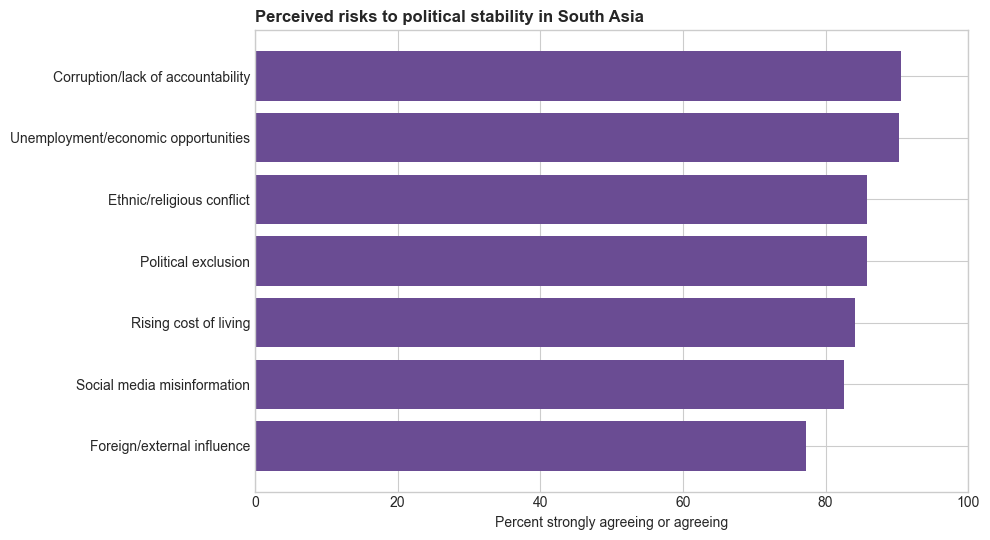

In [109]:
south_asia_risk_variables = ["q5_6_1", "q5_6_2", "q5_6_3", "q5_6_4", "q5_6_5", "q5_6_6", "q5_6_7"]
south_asia_plot = top_two_percent(south_asia_risk_variables).sort_values("Top two percent")

plt.figure(figsize=(10, 5.5))
plt.barh(south_asia_plot["Item"], south_asia_plot["Top two percent"], color="#6A4C93")
plt.title("Perceived risks to political stability in South Asia", loc="left", weight="bold")
plt.xlabel("Percent strongly agreeing or agreeing")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / "08_south_asia_risks.png", dpi=160)
plt.show()

**Interpretation.** The three risks receiving the most agreement are **Corruption/lack of accountability** (90.6%); **Unemployment/economic opportunities** (90.3%); **Political exclusion** (85.8%).

### Sources of hope for South Asia

### South Asia hope: Governance/anti-corruption reforms

In [110]:
frequency_table("q5_7_1")

South Asia hope: Governance/anti-corruption reforms
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,80,9.6
2,Agree,402,48.1
3,Neutral,185,22.1
4,Disagree,42,5.0
5,Strongly Disagree,46,5.5
6,Prefer not to say,80,9.6


**Interpretation.** The most common valid response was **Agree** (402 respondents; 48.1%). The valid denominator is 836.

### South Asia hope: Youth political participation

In [111]:
frequency_table("q5_7_2")

South Asia hope: Youth political participation
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,140,16.7
1,Agree,473,56.6
2,Neutral,125,15.0
3,Disagree,30,3.6
4,Strongly Disagree,5,0.6
5,Prefer not to say,63,7.5


**Interpretation.** The most common valid response was **Agree** (473 respondents; 56.6%). The valid denominator is 836.

### South Asia hope: Improved democracy

In [112]:
frequency_table("q5_7_3")

South Asia hope: Improved democracy
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Prefer not to say,1,0.1
1,Strongly Agree,77,9.2
2,Agree,410,49.0
3,Neutral,202,24.2
4,Disagree,61,7.3
5,Strongly Disagree,13,1.6
6,Prefer not to say,72,8.6


**Interpretation.** The most common valid response was **Agree** (410 respondents; 49.0%). The valid denominator is 836.

### South Asia hope: Economic/employment prospects

In [113]:
frequency_table("q5_7_4")

South Asia hope: Economic/employment prospects
Valid N = 836; missing or skipped = 0


,Response,Frequency,Valid percent
0,Strongly Agree,93,11.1
1,Agree,363,43.4
2,Neutral,186,22.2
3,Disagree,86,10.3
4,Strongly Disagree,35,4.2
5,Prefer not to say,73,8.7


**Interpretation.** The most common valid response was **Agree** (363 respondents; 43.4%). The valid denominator is 836.

## End of descriptive review

This notebook intentionally stops at simple, one-variable summaries. Subgroup comparisons, indices, hypothesis tests and regression analysis should be added only after the descriptive distributions and routing decisions have been reviewed.